# 💳 Credit Card Data Analysis


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
customer = pd.read_csv(r"C:\Users\Shubham Mishra\OneDrive\Pictures\Credit Card Case Study 2\Customer Acqusition.csv")
spend = pd.read_csv(r"C:\Users\Shubham Mishra\OneDrive\Pictures\Credit Card Case Study 2\spend.csv")
repayment = pd.read_csv(r"C:\Users\Shubham Mishra\OneDrive\Pictures\Credit Card Case Study 2\Repayment.csv")

In [8]:
customer.set_index(customer['No'],inplace =True)
customer.head(5)

,No,Customer,Age,City,Product,Limit,Company,Segment
No,,,,,,,,
1,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
2,2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
3,3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
4,4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
5,5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [9]:
spend.head()

,Sl No:,Customer,Month,Type,Amount
0,1,A1,12-Jan-04,JEWELLERY,485470.80
1,2,A1,3-Jan-04,PETRO,410556.13
2,3,A1,15-Jan-04,CLOTHES,23740.46
3,4,A1,25-Jan-04,FOOD,484342.47
4,5,A1,17-Jan-05,CAMERA,369694.07


In [10]:
repayment.head()

,SL No:,Customer,Month,Amount,Unnamed: 4
0,NaN,A1,12-Jan-04,495414.75,NaN
1,2.0,A1,3-Jan-04,245899.02,NaN
2,3.0,A1,15-Jan-04,259490.06,NaN
3,4.0,A1,25-Jan-04,437555.12,NaN
4,5.0,A1,17-Jan-05,165972.88,NaN


In [11]:
repayment.drop('Unnamed: 4' ,axis = 1,inplace =True)

In [11]:
repayment.head()

,SL No:,Customer,Month,Amount
0,NaN,A1,12-Jan-04,495414.75
1,2.0,A1,3-Jan-04,245899.02
2,3.0,A1,15-Jan-04,259490.06
3,4.0,A1,25-Jan-04,437555.12
4,5.0,A1,17-Jan-05,165972.88


# 1. In the above dataset,

# a. In case age is less than 18, replace it with mean of age values.


In [9]:
mean_age = customer['Age'].mean()

In [10]:
customer.loc[customer['Age'] < 18, 'Age'] = mean_age


# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 



In [11]:
cust_sped= pd.merge(customer , spend , how = 'inner', left_on = 'Customer', right_on ='Customer' )

In [12]:
cust_sped.loc[cust_sped['Amount'] > cust_sped['Limit'], 'Amount'] = cust_sped['Limit'] / 2

# c. Incase the repayment amount is more than the limit, replace the repayment with the limit.

In [13]:
 cust_repay = pd.merge(
    repayment,
    customer,
    how = 'inner',
    on = 'Customer')

In [14]:
cust_repay.loc[cust_repay['Amount'] > cust_repay['Limit'],'Amount'] = cust_repay['Limit']

# 2. From the above dataset create the following summaries:
# a. How many distinct customers exist?


In [15]:
cust_sped.Customer.nunique()


100

# b. How many distinct categories exist?

In [16]:
cust_sped['Type'].nunique()

15

# c. What is the average monthly spend by customers?


In [20]:
cust_sped['Month'] = pd.to_datetime(cust_sped['Month'], format='%b-%Y')
cust_sped['Months']  = cust_sped['Month'].dt.month
cust_sped['Month_names'] = cust_sped['Month'].dt.month_name()

In [23]:
cust_sped.groupby(['Months','Month_names']).agg({'Amount' : 'mean'})

,,Amount
Months,Month_names,
1,January,147770.183266
2,February,151261.565126
3,March,131840.761861
4,April,135035.927333
5,May,151623.982190
6,June,182037.731429
7,July,166326.817857
8,August,165759.596190
9,September,141131.704524


# d. What is the average monthly repayment by customers?


In [31]:
cust_repay['Month'] = pd.to_datetime(cust_repay['Month'], format='%b-%Y')

cust_repay['Month_names'] = cust_repay['Month'].dt.month_name()

cust_repay['Months'] = cust_repay['Month'].dt.month



cust_repay.groupby(['Months','Month_names']).agg({'Amount' : 'mean'})

,,Amount
Months,Month_names,
1,January,163445.534263
2,February,158873.098158
3,March,156430.854155
4,April,167676.814933
5,May,186097.903985
6,June,114146.549375
7,July,165203.918980
8,August,152817.425510
9,September,129345.768500


In [32]:
# If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 
# (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend.  Interest is 
# earned only on positive profits and not on negative amounts)

In [33]:
# 1. Monthly Spend
monthly_spend = cust_sped.groupby(['Customer', 'Months'])['Amount'].sum().reset_index()
monthly_spend.rename(columns={'Amount': 'Monthly_Spend'}, inplace=True)

# 2. Monthly Repayment
monthly_repay = cust_repay.groupby(['Customer', 'Months'])['Amount'].sum().reset_index()
monthly_repay.rename(columns={'Amount': 'Monthly_Repayment'}, inplace=True)

# 3. Merge both datasets
df = pd.merge(monthly_spend, monthly_repay, on=['Customer', 'Months'], how='inner')

# 4. Monthly Profit
df['Monthly_Profit'] = df['Monthly_Repayment'] - df['Monthly_Spend']

# 5. Bank Profit (Interest @ 2.9%)
df['Bank_Profit'] = df['Monthly_Profit'] * 0.029

# Final Output
print(df[['Customer', 'Months', 'Monthly_Profit', 'Bank_Profit']])

    Customer  Months  Monthly_Profit  Bank_Profit
0         A1       1      -201531.82  -5844.42278
1         A1       2       -94304.65  -2734.83485
2         A1       4       -14349.34   -416.13086
3         A1      11       387618.57  11240.93853
4        A10       1       608156.56  17636.54024
..       ...     ...             ...          ...
449      A95       1       129004.46   3741.12934
450      A96       1        45270.34   1312.83986
451      A97       1         5000.00    145.00000
452      A98       1         5000.50    145.01450
453      A99       1         5001.00    145.02900

[454 rows x 4 columns]


# f. What are the top 5 product types?


In [34]:
cust_sped.groupby('Type').agg({'Amount' : 'sum'}).sort_values(by = 'Amount' , ascending = False) .head(5)

,Amount
Type,
PETRO,28597384.98
CAMERA,27690738.44
FOOD,20519243.60
AIR TICKET,20155847.12
TRAIN TICKET,19995825.72


# g. Which city is having maximum spend?


In [35]:
cust_sped.groupby('City').agg({'Amount': 'sum'}).sort_values(by = 'Amount', ascending = False)

,Amount
City,
COCHIN,45963513.50
CALCUTTA,41108132.30
BANGALORE,40461647.02
BOMBAY,28603127.38
CHENNAI,22128635.65
TRIVANDRUM,15337155.87
PATNA,15260586.97
DELHI,10918286.54


# h. Which age group is spending more money?


In [36]:
cust_sped['Bins'] = pd.cut(cust_sped['Age'],bins = 10)

In [37]:
 cust_sped.groupby('Bins',observed=True).agg({'Amount': 'sum'}).sort_values(by = 'Amount' , ascending = False).head(1)

,Amount
Bins,
"(43.0, 49.0]",39907148.99


# i. Who are the top 10 customers in terms of repayment?


In [38]:
cust_repay.groupby('Customer').agg(Repayment = ('Amount', 'sum')).sort_values(by = 'Repayment', ascending = False).head(10)

,Repayment
Customer,
A61,10539142.91
A60,9876290.74
A13,9572000.66
A43,8489871.46
A45,8448334.87
A12,8334760.16
A14,7943268.63
A44,7744730.12
A39,7622483.30


# 3. Calculate the city wise spend on each product on yearly basis. Also include a graphical  representation for the same.

In [39]:
cust_sped['year'] = cust_sped['Month'].dt.year

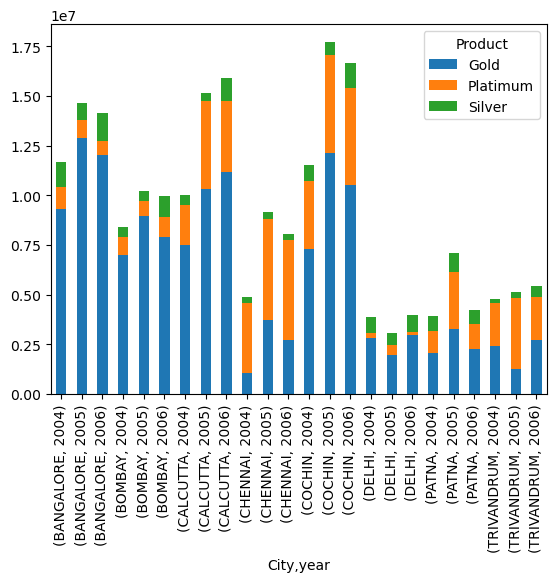

In [45]:
df = cust_sped.pivot_table(
               values = 'Amount',
               aggfunc ='sum',
               index = ['City','year'],
               columns = 'Product'
              )

df.plot(kind = 'bar',stacked = True
       )

plt.show()

# 4. Create graphs for
# a. Monthly comparison of total spends, city wise


<Axes: xlabel='Months'>

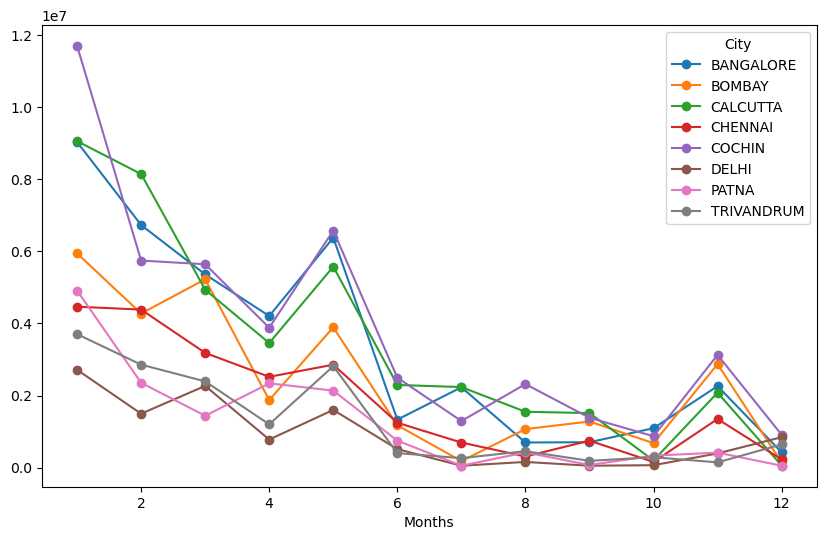

In [48]:
import matplotlib.pyplot as plt
grouped = cust_sped.groupby(['City', 'Months'])['Amount'].sum().reset_index()
pivot_df = grouped.pivot(index='Months', columns='City', values='Amount')


pivot_df.plot(kind='line', figsize=(10,6), marker='o')

Text(0.5, 1.0, 'Year wise Air Ticket Spend')

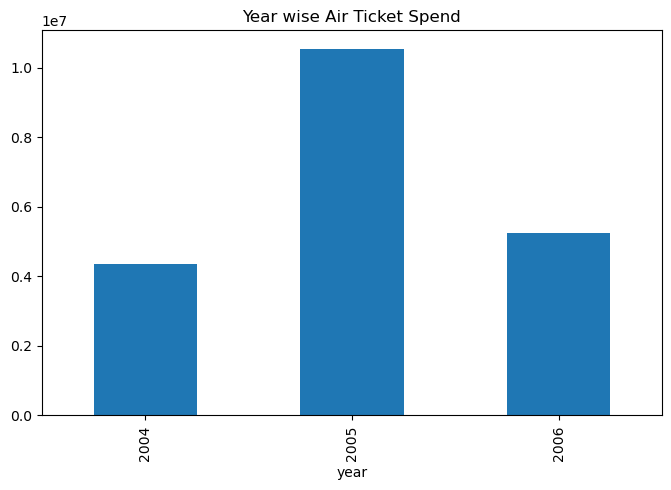

In [30]:
# b. Comparison of yearly spend on air tickets
df = cust_sped[cust_sped['Type'] == 'AIR TICKET']
grouped =df.groupby('year')['Amount'].sum()


grouped.plot(x='year', y='Amount', kind='bar', figsize=(8,5),)
plt.title("Year wise Air Ticket Spend")


In [31]:
# c. Comparison of monthly spend for each product (look for any seasonality
# that exists in terms of spend

<Axes: xlabel='Month'>

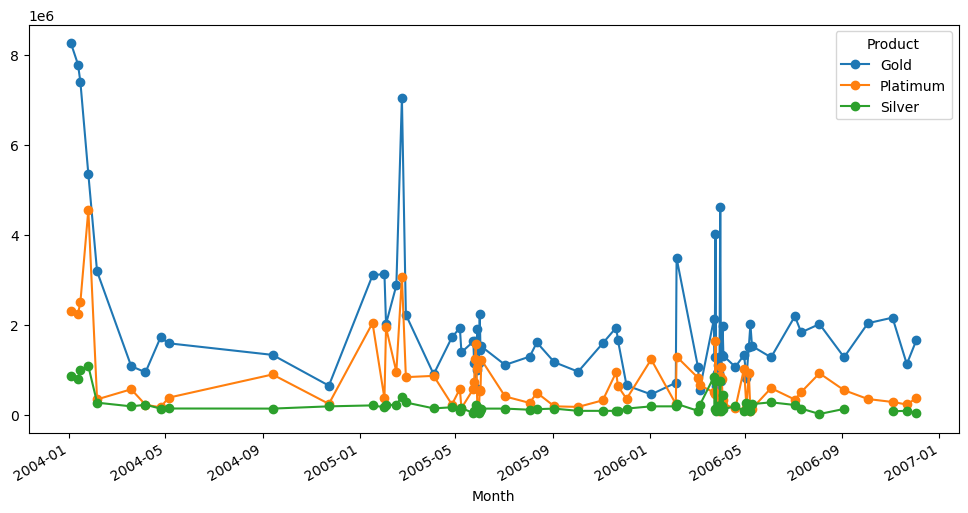

In [32]:
grouped = cust_sped.groupby(['Product', 'Month'])['Amount'].sum().reset_index()
pivot_df = grouped.pivot(index='Month', columns='Product', values='Amount')
pivot_df.plot(kind='line', marker='o', figsize=(12,6))

In [33]:
# You need to find top 10 customers for each city in terms of their repayment amount by 
# different products and by different time periods i.e. year or month. The user should be able 
# to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the 
# function should automatically take these inputs while identifying the top 10 customers.

In [49]:


def top_10_customers(cust_repay, product, time_period):
        
    # Extract time
    if time_period.lower() == 'yearly':
        
        cust_repay['Time'] = cust_repay['Month'].dt.year
    elif time_period.lower() == 'monthly':
        cust_repay['Time'] = cust_repay['Month'].dt.month
    else:
        print("Invalid time period! Use 'yearly' or 'monthly'")
        return
    
    # Filter product
    df = cust_repay[cust_repay['Product'] == product]
    
    # Group data
    grouped = df.groupby(['City', 'Time', 'Customer'])['Amount'].sum().reset_index()
    
    # Sort values
    grouped = grouped.sort_values(['City', 'Time', 'Amount'], ascending=[True, True, False])

    # Get top 10 per City & Time
    top10 = grouped.groupby(['City', 'Time']).head(10)
    
    return top10

In [51]:

top_10_customers(cust_repay,'Gold','monthly')

,City,Time,Customer,Amount
0,BANGALORE,1,A1,2407806.29
1,BANGALORE,1,A13,2014186.98
4,BANGALORE,1,A43,1978038.15
2,BANGALORE,1,A14,993114.87
3,BANGALORE,1,A30,608066.49
...,...,...,...,...
206,TRIVANDRUM,4,A28,115326.71
207,TRIVANDRUM,5,A28,2233253.41
208,TRIVANDRUM,7,A28,380460.40
209,TRIVANDRUM,8,A28,437823.07
